## 1. Import Necessary Libraries


In [1]:
# 1. Install missing dependencies (Jupyter Magic Command)
%pip install -q numpy pandas matplotlib seaborn scikit-learn imbalanced-learn xgboost lightgbm catboost interpret shap statsmodels joblib

# 2. Import the Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, time

# ML and Preprocessing
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, matthews_corrcoef, classification_report,
                             precision_recall_curve, balanced_accuracy_score)

# Imbalanced Learn Pipeline & SMOTE
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Baseline linear models (kept for McNemar continuity with v2)
from sklearn.linear_model import RidgeClassifier, PassiveAggressiveClassifier, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, ExtraTreesClassifier

# v3 base models: diversity-driven trio
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier            # reference row only in v3
from interpret.glassbox import ExplainableBoostingClassifier

# Explainability & stats
import shap
import joblib
from scipy.stats import spearmanr, kendalltau
from statsmodels.stats.contingency_tables import mcnemar as mc_test

import warnings
warnings.filterwarnings('ignore')
print("All modules loaded successfully! Ready to continue.")


Note: you may need to restart the kernel to use updated packages.
All modules loaded successfully! Ready to continue.


## 2. Dynamic Data Loading

In [2]:
import numpy as np
import pandas as pd

def load_dataset():
    print("Loading Primary Dataset: CICIDS-2017")
    df = pd.read_csv('CICIDS-2017.csv')
    
    # 1. Strip all invisible spaces from column names!
    df.columns = df.columns.str.strip()
    
    # 2. Standardize the target column name to lowercase 'label'
    if 'Label' in df.columns:
        df.rename(columns={'Label': 'label'}, inplace=True)

    # 2b. Repair mojibake in label strings. CICIDS-2017 label files use a
    #     cp1252 en-dash (0x96) that decodes to U+FFFD '\ufffd' under utf-8,
    #     producing 'Web Attack \ufffd Brute Force' in every figure/table.
    #     Normalise to a plain ASCII hyphen and collapse whitespace.
    if 'label' in df.columns:
        df['label'] = (df['label'].astype(str)
                       .str.replace('\ufffd', '-', regex=False)
                       .str.replace('\u0096', '-', regex=False)
                       .str.replace('\u2013', '-', regex=False)
                       .str.replace(r'\s+', ' ', regex=True)
                       .str.strip())
        
    # 3. Clean up infinite values and NaNs that are common in CICIDS-2017
    print("Cleaning infinite values and NaNs...")
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    
    return df

data = load_dataset()
data.head()

Loading Primary Dataset: CICIDS-2017
Cleaning infinite values and NaNs...


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,label
0,22,166,1,1,0,0,0,0,0.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
1,60148,83,1,2,0,0,0,0,0.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
2,123,99947,1,1,48,48,48,48,48.0,0.0,...,40,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
3,123,37017,1,1,48,48,48,48,48.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
4,0,111161336,147,0,0,0,0,0,0.0,0.0,...,0,1753752.625,2123197.578,4822992,95,9463032.7,2657727.996,13600000,5700287,BENIGN


## 3. Data Preprocessing


In [3]:
print("Preprocessing data...")
data.fillna(0, inplace=True)

categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
if 'label' in categorical_cols:
    categorical_cols.remove('label')

if len(categorical_cols) > 0:
    data = pd.get_dummies(data, drop_first=True, columns=categorical_cols)

label_encoder = LabelEncoder()
data['label'] = label_encoder.fit_transform(data['label'])

X = data.drop('label', axis=1)
y = data['label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(f"Shape of X: {X_scaled.shape}")
print(f"Shape of y: {y.shape}")


Preprocessing data...
Shape of X: (2827876, 78)
Shape of y: (2827876,)


## 4. Hybrid Feature Selection (MI + Random Forest)

In [4]:
print("Running Hybrid Feature Selection...")

# 1. Mutual Information Filter.
#    OPTIMISATION: this MI pass is the single most expensive step on large data.
#    We compute it ONCE here and cache the full ranking as `ranked_features`,
#    so the feature-count ablation (Sec 4b) does NOT recompute it.
mi_selector = SelectKBest(score_func=mutual_info_classif, k=min(30, X_scaled.shape[1]))
mi_selector.fit(X_scaled, y)
mi_features = X_scaled.columns[mi_selector.get_support()]

# 2. Random Forest importance wrapper (ranks the MI-filtered candidates).
rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_scaled[mi_features], y)
importances = rf.feature_importances_

# Full hybrid ranking, best -> worst (cached for reuse).
ranked_features = list(mi_features[np.argsort(importances)[::-1]])

# v4: the feature-count ablation (Sec 4b, executed in v3) showed K=25 beats
# K=20 by ~0.5 pp validation accuracy (0.9978 vs 0.9926) with K=30 adding
# nothing (0.9976). We therefore adopt the TOP 25 features, justified by the
# ablation itself. Report this decision explicitly in the manuscript.
SELECTED_K = 25
selected_features = ranked_features[:SELECTED_K]
print(f"Selected Top {SELECTED_K} Features: {selected_features}")

X_selected = X_scaled[selected_features]


Running Hybrid Feature Selection...
Selected Top 25 Features: ['Bwd Packet Length Std', 'Packet Length Std', 'Bwd Packet Length Mean', 'Bwd Packet Length Max', 'Subflow Fwd Bytes', 'Packet Length Variance', 'Destination Port', 'Subflow Bwd Bytes', 'Average Packet Size', 'Packet Length Mean', 'Avg Bwd Segment Size', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Init_Win_bytes_forward', 'Max Packet Length', 'Avg Fwd Segment Size', 'Fwd Header Length', 'Fwd Packet Length Mean', 'Fwd Packet Length Max', 'Fwd Header Length.1', 'Fwd IAT Max', 'Fwd IAT Mean', 'Init_Win_bytes_backward', 'Flow IAT Mean', 'Flow IAT Max']


## 4c. Prepare Evaluation Subset (+ capped SMOTE)

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder as _LE
from collections import Counter

# ── Capped SMOTE ──────────────────────────────────────────────────────────────
# Default SMOTE lifts every minority class to the majority count.  With BENIGN
# at ~2.3 M flows that creates a ~25 M-row training set → OOM risk on 16 GB.
# capped_sampling lifts rare classes to at most SMOTE_CAP samples.
SMOTE_CAP = 50_000

def capped_sampling(y_arr):
    counts  = Counter(list(y_arr))
    ceiling = min(SMOTE_CAP, max(counts.values()))
    return {cls: (n if n >= ceiling else ceiling) for cls, n in counts.items()}

def make_smote():
    """Auto-tune k_neighbors so SMOTE never requests more neighbours than
    samples in the rarest class's training fold.
    Uses the 3-fold fraction (2/3) as the conservative worst-case split so the
    same helper is safe for both the 3-fold sweep and the 5-fold main CV."""
    min_n       = min(Counter(list(y_subset)).values())
    safe_train  = max(1, int(min_n * 2 / 3))   # samples per class per train fold
    k           = max(1, min(5, safe_train - 1))
    return SMOTE(sampling_strategy=capped_sampling, k_neighbors=k, random_state=42)

# ── Row-index alignment ───────────────────────────────────────────────────────
# X_scaled has RangeIndex 0..N-1 (from StandardScaler); y has the original
# (potentially gapped) index from data['label'] after dropna.  Reset both.
X_selected_r = X_selected.reset_index(drop=True)
X_scaled_r   = X_scaled.reset_index(drop=True)
y_r          = y.reset_index(drop=True)

# ── Step 1: Optional stratified subsample ────────────────────────────────────
# FULL_RUN is the single switch for a camera-ready full-data run. When True it
# uses the entire dataset here AND uncaps EBM in the model-zoo cell (Sec 5).
#   FULL_RUN = False -> fast 20% development run  (~2 h on M2 Pro 16 GB)
#   FULL_RUN = True  -> camera-ready full run     (~4-6 h, plugged in, EBM uncapped)
FULL_RUN = False   # <<< SET True FOR THE CAMERA-READY FULL-DATA RUN
SUBSAMPLE_FRACTION = 1.0 if FULL_RUN else 0.20
if SUBSAMPLE_FRACTION < 1.0:
    print(f"Taking a {int(SUBSAMPLE_FRACTION*100)}% stratified sample...")
    all_idx = np.arange(len(y_r))
    _, sub_idx = train_test_split(
        all_idx, test_size=SUBSAMPLE_FRACTION,
        stratify=y_r, random_state=42)
else:
    print("Using the FULL dataset (no subsampling).")
    sub_idx = np.arange(len(y_r))

# ── Step 2: Filter ultra-rare classes AFTER subsampling ──────────────────────
# Filtering on the full dataset and then subsampling can leave classes with too
# few post-subsample rows for SMOTE's k-NN (caused k_neighbors > n_samples error).
# With 3-fold CV the training fold has 2/3 of subsample rows per class.
# To safely use k_neighbors ≤ 5 (needs 6 neighbours) we need ≥ ceil(6/(2/3)) = 9
# rows; MIN_CLASS_SAMPLES = 15 gives comfortable headroom.
MIN_CLASS_SAMPLES = 15
y_sub_raw    = y_r.iloc[sub_idx].reset_index(drop=True)
class_counts = y_sub_raw.value_counts()
valid_classes = class_counts[class_counts >= MIN_CLASS_SAMPLES].index
keep_mask    = y_sub_raw.isin(valid_classes)
final_idx    = sub_idx[keep_mask.values]

removed = len(class_counts) - len(valid_classes)
print(f"Post-subsample filter: removed {removed} class(es) with "
      f"< {MIN_CLASS_SAMPLES} samples in the subset.")

# ── Build aligned subsets ─────────────────────────────────────────────────────
X_subset      = X_selected_r.iloc[final_idx].reset_index(drop=True)
y_subset_raw  = y_r.iloc[final_idx].reset_index(drop=True)
X_full_subset = X_scaled_r.iloc[final_idx].reset_index(drop=True)  # all features, same rows

# ── Consecutive label re-encoding ────────────────────────────────────────────
# After filtering, gaps appear in the label encoding (e.g. classes 8, 9 removed
# leaves [0,1,2,3,4,5,6,7,10,11,12,14]).  XGBoost's sklearn wrapper requires
# labels in [0, n_classes) and throws "Invalid classes" when it sees gaps.
# We re-encode to consecutive integers here so every model sees clean labels.
#
# class_names_subset[i] = the attack-class name for new consecutive label i.
# Use this everywhere label_encoder.classes_ was previously used for display.
subset_le         = _LE()
y_subset          = pd.Series(
    subset_le.fit_transform(y_subset_raw), name="label", dtype=int)
class_names_subset = [label_encoder.classes_[orig] for orig in subset_le.classes_]

print(f"\nEvaluation subset : {X_subset.shape} | "
      f"{y_subset.nunique()} classes | "
      f"min class size = {y_subset.value_counts().min()}")
print(f"make_smote() will use k_neighbors = "
      f"{max(1, min(5, int(y_subset.value_counts().min()*2/3) - 1))} (auto-tuned)")
print("\nClass label map (new consecutive → original attack name):")
for new_i, name in enumerate(class_names_subset):
    print(f"  {new_i:2d}  {name}")


Taking a 20% stratified sample...
Post-subsample filter: removed 3 class(es) with < 15 samples in the subset.

Evaluation subset : (565563, 25) | 12 classes | min class size = 130
make_smote() will use k_neighbors = 5 (auto-tuned)

Class label map (new consecutive → original attack name):
   0  BENIGN
   1  Bot
   2  DDoS
   3  DoS GoldenEye
   4  DoS Hulk
   5  DoS Slowhttptest
   6  DoS slowloris
   7  FTP-Patator
   8  PortScan
   9  SSH-Patator
  10  Web Attack - Brute Force
  11  Web Attack - XSS


## 4b. Feature-Count Ablation (Figure 1)

K=10 features -> validation accuracy 0.9491
K=15 features -> validation accuracy 0.9887
K=20 features -> validation accuracy 0.9926
K=25 features -> validation accuracy 0.9978
K=30 features -> validation accuracy 0.9976


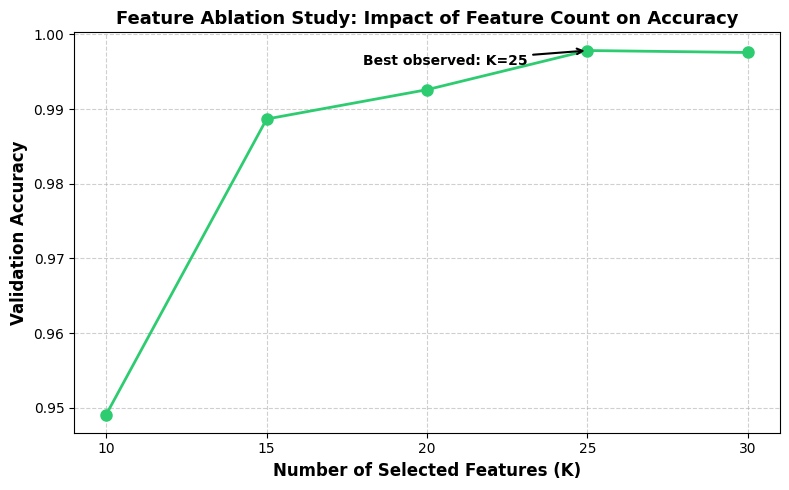


Saved -> Fig1_Feature_Ablation.png
NOTE: annotate the chosen K honestly. If K=20 is kept despite a higher-
accuracy K, justify it as an accuracy-latency trade-off in the paper.


In [6]:
# Feature-count ablation -> regenerates Figure 1 from real runs.
# v3 NOTE: the sweep uses a fast CatBoost + ExtraTrees soft-voting proxy.
# EBM is EXCLUDED here purely for computational cost (5 K-values x 3 folds
# would mean 15 extra EBM fits). The feature-subset decision does not depend
# on the glass-box member; disclose this in the manuscript's ablation text.
from sklearn.model_selection import cross_val_score

assert 'ranked_features' in globals(), 'Run the feature-selection cell (Sec 4) first.'
assert 'X_full_subset' in globals(), 'Run the subset-prep cell (Sec 4c) first.'

K_values = [10, 15, 20, 25, 30]
feat_sweep_acc = []
skf_fast = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for K in K_values:
    feats_K = ranked_features[:K]
    Xk = X_full_subset[feats_K]
    ens_K = VotingClassifier(estimators=[
        ('CatBoost', CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1,
                                        loss_function='MultiClass', random_seed=42,
                                        verbose=0, thread_count=-1)),
        ('ExtraTrees', ExtraTreesClassifier(n_estimators=150, n_jobs=-1,
                                            random_state=42)),
    ], voting='soft')
    pipe_K = Pipeline([('smote', make_smote()), ('classifier', ens_K)])
    # n_jobs=1 on the outer CV avoids nested parallelism with the inner
    # multi-threaded models, preventing CPU oversubscription on M2.
    scores = cross_val_score(pipe_K, Xk, y_subset, cv=skf_fast, scoring='accuracy', n_jobs=1)
    feat_sweep_acc.append(np.mean(scores))
    print(f'K={K:2d} features -> validation accuracy {np.mean(scores):.4f}')

plt.figure(figsize=(8, 5))
plt.plot(K_values, feat_sweep_acc, marker='o', linewidth=2, color='#2ecc71', markersize=8)
best_K = K_values[int(np.argmax(feat_sweep_acc))]
plt.annotate(f'Best observed: K={best_K}',
             xy=(best_K, max(feat_sweep_acc)),
             xytext=(best_K - 7, max(feat_sweep_acc) - 0.002),
             fontsize=10, fontweight='bold',
             arrowprops=dict(arrowstyle='->', lw=1.5))
plt.title('Feature Ablation Study: Impact of Feature Count on Accuracy',
          fontsize=13, fontweight='bold')
plt.xlabel('Number of Selected Features (K)', fontsize=12, fontweight='bold')
plt.ylabel('Validation Accuracy', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(K_values)
plt.tight_layout()
plt.savefig('Fig1_Feature_Ablation.png', dpi=300, bbox_inches='tight')
plt.show()
print('\nSaved -> Fig1_Feature_Ablation.png')
print(f'NOTE: annotate the chosen K honestly. If K=20 is kept despite a higher-')
print(f'accuracy K, justify it as an accuracy-latency trade-off in the paper.')


## 5. Model Zoo — Diversity-Driven Glass-Box Ensemble (v3)

Three base learners with **different learning paradigms** (the v2 ablation showed
that homogeneous boosters make correlated errors and fail to beat their best member):

| Member | Paradigm | Role |
|---|---|---|
| CatBoost | Ordered boosting on symmetric (oblivious) trees | Strong learner |
| ExtraTrees | Extremely randomised bagging | Decorrelated variance reducer |
| EBM | Cyclic-boosted additive GAM (**glass-box**) | Novelty + trust anchor |

Plus: **LightGBM** as the strongest-single-model *reference row* (not an ensemble
member), and the v2 linear baseline for McNemar continuity.

All hyperparameters below are disclosed for the manuscript's Table A.


In [7]:
# =====================================================================
# MODEL ZOO (v3) — hyperparameters disclosed here -> paper Table A
# CatBoost  : iterations=200, depth=6, learning_rate=0.1, MultiClass loss
# ExtraTrees: n_estimators=200, unlimited depth, gini
# EBM       : max_bins=64, interactions=0 (required for multiclass),
#             outer_bags=2, max_rounds=2000 (runtime-tuned; v3 took ~6,500 s/fold
#             at 250k rows/128 bins — all reductions disclosed in the paper)
# Meta      : LogisticRegression (multinomial), trained on blend-set probs
# Reference : LightGBM n_estimators=100, lr=0.1, max_depth=6
# Baseline  : Ridge=1, NB=1, PAC=4 soft voting (unchanged from v2)
# =====================================================================

# EBM runtime knob: cap EBM's per-fold training rows (stratified). FULL_RUN
# (set in the subset-prep cell, Sec 4c) lifts the cap for the camera-ready run.
# DISCLOSE the value actually used in the manuscript (Table A).
FULL_RUN = globals().get('FULL_RUN', False)
EBM_TRAIN_CAP = None if FULL_RUN else 100_000   # None = uncapped (full run)

def fresh_base_models():
    """Return NEW instances each call (avoid state leakage across folds)."""
    return {
        'CatBoost': CatBoostClassifier(
            iterations=200, depth=6, learning_rate=0.1,
            loss_function='MultiClass', random_seed=42,
            verbose=0, thread_count=-1),
        'ExtraTrees': ExtraTreesClassifier(
            n_estimators=200, n_jobs=-1, random_state=42),
        'EBM': ExplainableBoostingClassifier(
            max_bins=64, interactions=0, outer_bags=2, max_rounds=2000,
            n_jobs=-1, random_state=42),
    }

def fresh_reference_models():
    return {
        'LightGBM (reference)': LGBMClassifier(
            n_estimators=100, learning_rate=0.1, max_depth=6,
            random_state=42, n_jobs=-1, verbose=-1),
    }

def fresh_baseline():
    ridge = CalibratedClassifierCV(RidgeClassifier(class_weight='balanced'), cv=3)
    nbay  = GaussianNB()
    pac   = CalibratedClassifierCV(
        PassiveAggressiveClassifier(max_iter=1000, random_state=42), cv=3)
    return VotingClassifier(estimators=[
        ('Ridge', ridge), ('Naive Bayes', nbay), ('Passive Aggressive', pac)
    ], voting='soft', weights=[1, 1, 4])

def fresh_meta():
    return LogisticRegression(max_iter=1000, random_state=42)

VOTE_KEY   = 'Voting (CB+ET+EBM)'
STACK_KEY  = 'Stacking (CB+ET+EBM)'
THRESH_KEY = 'Stacking + Thresholds'
BASE_KEY   = 'Baseline Ensemble'

# Fraction of each ORIGINAL training fold held out (untouched, real class
# prevalence) for per-class decision-threshold calibration. SMOTE never sees it.
CAL_FRACTION = 0.10
print('Model zoo defined. Keys:', VOTE_KEY, '|', STACK_KEY, '|', THRESH_KEY)


Model zoo defined. Keys: Voting (CB+ET+EBM) | Stacking (CB+ET+EBM) | Stacking + Thresholds


## 6. Unified 5-Fold Evaluation Harness (leak-proof SMOTE)

**Design.** Per outer fold: SMOTE the training fold (capped, leak-proof), split it
80/20 (fit-part / blend-part), fit **each base model once** on the fit-part, then:

- **Standalone metrics** per base model — from its test-fold predictions.
- **Soft voting** — unweighted mean of the stored base probabilities.
- **Stacking (blending)** — logistic-regression meta-learner trained on the
  blend-part probabilities, applied to the test-fold probabilities.
- **Reference (LightGBM)** and **linear baseline** fitted on the same fit-part
  so every comparison shares identical data and folds.

One fit per base per fold ⇒ only **5 EBM fits total**, and all McNemar tests are
properly paired. The 80/20 internal split is a disclosed design choice (blending
rather than full k-fold stacking) made for the glass-box member's runtime.


In [8]:
# Unified harness v4: standalone + voting + stacking + threshold-calibrated
# stacking + references — all on identical folds, leak-free throughout.
#
# Per fold:
#   1. Carve a 10% UNTOUCHED calibration slice (real prevalence) from the
#      training fold. SMOTE and all model fitting never see it.
#   2. Capped SMOTE on the remaining 90%; split 80/20 fit/blend.
#   3. Fit each base ONCE on fit-part; meta (LR) on blend probabilities.
#   4. Tune per-class thresholds on the calibration slice's meta probabilities
#      (maximise per-class F1 via the precision-recall curve), then apply
#      threshold-moving (argmax of p_c / t_c) to the TEST probabilities.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
n_classes = int(y_subset.nunique())

ALL_KEYS = ['CatBoost', 'ExtraTrees', 'EBM', 'LightGBM (reference)',
            BASE_KEY, VOTE_KEY, STACK_KEY, THRESH_KEY]
fold_metrics = {k: {'acc': [], 'f1': [], 'f1_macro': [], 'mcc': [],
                    'inf_us': [], 'inf_par_us': []} for k in ALL_KEYS}
pooled_preds = {k: [] for k in ALL_KEYS}
pooled_true  = []
fold_thresholds = []
fitted_bases = None
fitted_meta  = None

def record(key, y_te, y_hat, inf_us, inf_par_us=None):
    fold_metrics[key]['acc'].append(accuracy_score(y_te, y_hat))
    fold_metrics[key]['f1'].append(f1_score(y_te, y_hat, average='weighted'))
    fold_metrics[key]['f1_macro'].append(f1_score(y_te, y_hat, average='macro'))
    fold_metrics[key]['mcc'].append(matthews_corrcoef(y_te, y_hat))
    fold_metrics[key]['inf_us'].append(inf_us)
    fold_metrics[key]['inf_par_us'].append(inf_par_us if inf_par_us is not None else inf_us)
    pooled_preds[key].extend(y_hat)

t_start = time.time()
for fold_i, (train_idx, test_idx) in enumerate(skf.split(X_subset, y_subset), 1):
    print(f"\n===== Fold {fold_i}/5 =====")
    X_tr, X_te = X_subset.iloc[train_idx], X_subset.iloc[test_idx]
    y_tr, y_te = y_subset.iloc[train_idx], y_subset.iloc[test_idx]
    pooled_true.extend(y_te)

    # 1. Untouched calibration slice (real prevalence) for threshold tuning
    X_core, X_cal, y_core, y_cal = train_test_split(
        X_tr, y_tr, test_size=CAL_FRACTION, stratify=y_tr, random_state=42)

    # 2. Leak-proof capped SMOTE on the core only
    sm = make_smote()
    X_res, y_res = sm.fit_resample(X_core, y_core)
    X_fit, X_blend, y_fit, y_blend = train_test_split(
        X_res, y_res, test_size=0.20, stratify=y_res, random_state=42)
    print(f"fit={len(X_fit):,} blend={len(X_blend):,} cal={len(X_cal):,} test={len(X_te):,}")

    bases = fresh_base_models()
    P_blend, P_test, P_cal = {}, {}, {}
    member_inf = {}

    for name, model in bases.items():
        if name == 'EBM' and EBM_TRAIN_CAP is not None and len(X_fit) > EBM_TRAIN_CAP:
            X_ebm, _, y_ebm, _ = train_test_split(
                X_fit, y_fit, train_size=EBM_TRAIN_CAP,
                stratify=y_fit, random_state=42)
            print(f"  EBM training capped at {EBM_TRAIN_CAP:,} rows (of {len(X_fit):,})")
        else:
            X_ebm, y_ebm = X_fit, y_fit

        t0 = time.time()
        model.fit(X_ebm if name == 'EBM' else X_fit,
                  y_ebm if name == 'EBM' else y_fit)
        fit_s = time.time() - t0

        P_blend[name] = model.predict_proba(X_blend)
        P_cal[name]   = model.predict_proba(X_cal)
        t0 = time.time()
        P_test[name]  = model.predict_proba(X_te)
        inf_us = (time.time() - t0) / len(X_te) * 1e6
        member_inf[name] = inf_us

        y_hat = np.argmax(P_test[name], axis=1)
        record(name, y_te, y_hat, inf_us)
        print(f"  {name:12s} fit {fit_s:7.1f}s | acc {fold_metrics[name]['acc'][-1]:.4f} "
              f"| wF1 {fold_metrics[name]['f1'][-1]:.4f} "
              f"| mF1 {fold_metrics[name]['f1_macro'][-1]:.4f}")

    seq_lat = sum(member_inf.values())          # sequential member execution
    par_lat = max(member_inf.values())          # members run in parallel

    # --- Soft voting (no extra fits) ---
    Pv = np.mean([P_test[n] for n in bases], axis=0)
    record(VOTE_KEY, y_te, np.argmax(Pv, axis=1), seq_lat, par_lat)

    # --- Stacking (blending): LR meta on blend-part probabilities ---
    meta = fresh_meta()
    Zb   = np.hstack([P_blend[n] for n in bases])
    Zt   = np.hstack([P_test[n]  for n in bases])
    Zc   = np.hstack([P_cal[n]   for n in bases])
    meta.fit(Zb, y_blend)
    t0 = time.time()
    Pt_meta = meta.predict_proba(Zt)
    meta_us = (time.time() - t0) / len(X_te) * 1e6
    record(STACK_KEY, y_te, np.argmax(Pt_meta, axis=1),
           seq_lat + meta_us, par_lat + meta_us)

    # --- 4. Per-class threshold calibration on the UNTOUCHED slice ---
    Pcal_meta = meta.predict_proba(Zc)
    y_cal_arr = np.asarray(y_cal)
    thr = np.full(n_classes, 0.5)
    for c in range(n_classes):
        y_bin = (y_cal_arr == c).astype(int)
        if y_bin.sum() < 3 or y_bin.sum() == len(y_bin):
            continue   # too few positives to tune; keep default
        prec, rec, t = precision_recall_curve(y_bin, Pcal_meta[:, c])
        f1s = 2 * prec * rec / np.clip(prec + rec, 1e-12, None)
        f1s = f1s[:-1]                      # align with thresholds array
        if len(f1s) == 0 or not np.isfinite(f1s).any():
            continue
        thr[c] = float(np.clip(t[int(np.nanargmax(f1s))], 1e-6, 1 - 1e-6))
    fold_thresholds.append(thr.copy())
    y_hat_thr = np.argmax(Pt_meta / thr[None, :], axis=1)
    record(THRESH_KEY, y_te, y_hat_thr, seq_lat + meta_us, par_lat + meta_us)
    print(f"  {STACK_KEY}: mF1 {fold_metrics[STACK_KEY]['f1_macro'][-1]:.4f} -> "
          f"{THRESH_KEY}: mF1 {fold_metrics[THRESH_KEY]['f1_macro'][-1]:.4f}")

    # --- References on the SAME fit-part (fairness) ---
    for name, model in fresh_reference_models().items():
        model.fit(X_fit, y_fit)
        t0 = time.time(); y_hat = model.predict(X_te)
        record(name, y_te, y_hat, (time.time() - t0) / len(X_te) * 1e6)

    bl = fresh_baseline()
    bl.fit(X_fit, y_fit)
    t0 = time.time(); y_hat = bl.predict(X_te)
    record(BASE_KEY, y_te, y_hat, (time.time() - t0) / len(X_te) * 1e6)

    if fold_i == skf.get_n_splits():
        fitted_bases, fitted_meta = bases, meta

print(f"\nTotal harness time: {(time.time()-t_start)/60:.1f} min")
mean_thresholds = np.mean(np.stack(fold_thresholds), axis=0)
print("Mean tuned thresholds per class:")
for c in range(n_classes):
    print(f"  {class_names_subset[c]:28s} t = {mean_thresholds[c]:.4f}")

mcnemar_data = {k: list(v) for k, v in pooled_preds.items()}
mcnemar_data['true'] = list(pooled_true)
y_true_all = np.array(pooled_true)



===== Fold 1/5 =====
fit=701,656 blend=175,415 cal=45,245 test=113,113
  CatBoost     fit   134.3s | acc 0.9942 | wF1 0.9953 | mF1 0.8176
  ExtraTrees   fit    32.5s | acc 0.9982 | wF1 0.9982 | mF1 0.8975
  EBM training capped at 100,000 rows (of 701,656)
  EBM          fit   304.8s | acc 0.9925 | wF1 0.9943 | mF1 0.8120
  Stacking (CB+ET+EBM): mF1 0.8883 -> Stacking + Thresholds: mF1 0.8921

===== Fold 2/5 =====
fit=701,656 blend=175,415 cal=45,245 test=113,113
  CatBoost     fit   138.0s | acc 0.9944 | wF1 0.9955 | mF1 0.8317
  ExtraTrees   fit    31.5s | acc 0.9983 | wF1 0.9984 | mF1 0.9038
  EBM training capped at 100,000 rows (of 701,656)
  EBM          fit   321.5s | acc 0.9930 | wF1 0.9947 | mF1 0.8228
  Stacking (CB+ET+EBM): mF1 0.9000 -> Stacking + Thresholds: mF1 0.8879

===== Fold 3/5 =====
fit=701,656 blend=175,415 cal=45,245 test=113,113
  CatBoost     fit   132.6s | acc 0.9933 | wF1 0.9946 | mF1 0.8097
  ExtraTrees   fit    32.0s | acc 0.9980 | wF1 0.9981 | mF1 0.8979
  

## 6b. Component Ablation & Table 1 (assembled from the harness — no extra fits)

In [9]:
# Assemble Table 1 (v4): weighted F1 + macro F1 + dual latency accounting.
rows = {}
for k in ALL_KEYS:
    rows[k] = {
        'Accuracy': np.mean(fold_metrics[k]['acc']),
        'F1_weighted': np.mean(fold_metrics[k]['f1']),
        'F1_macro': np.mean(fold_metrics[k]['f1_macro']),
        'MCC': np.mean(fold_metrics[k]['mcc']),
        'Lat_seq_us': np.mean(fold_metrics[k]['inf_us']),
        'Lat_par_us': np.mean(fold_metrics[k]['inf_par_us']),
    }
order = [BASE_KEY, 'LightGBM (reference)', 'CatBoost', 'ExtraTrees', 'EBM',
         VOTE_KEY, STACK_KEY, THRESH_KEY]
table1 = pd.DataFrame(rows).T.loc[order].round(4)
print('================ TABLE 1 (copy into manuscript) ================')
print(table1.to_string())
table1.to_csv('Table1_v4_component_ablation.csv')
print('\nSaved -> Table1_v4_component_ablation.csv')
print('NOTE: Lat_seq = members executed sequentially; Lat_par = members in')
print('parallel (deployment-realistic) + meta overhead. Report both.')

base_names = ['CatBoost', 'ExtraTrees', 'EBM']
best_base = max(base_names, key=lambda n: rows[n]['F1_weighted'])
for comb in (VOTE_KEY, STACK_KEY):
    v = 'BEATS' if rows[comb]['F1_weighted'] >= rows[best_base]['F1_weighted'] else 'does NOT beat'
    print(f"{comb}: wF1={rows[comb]['F1_weighted']:.4f} {v} best base "
          f"({best_base}, wF1={rows[best_base]['F1_weighted']:.4f})")
ref = 'LightGBM (reference)'
for comb in (VOTE_KEY, STACK_KEY):
    v = 'BEATS' if rows[comb]['F1_weighted'] >= rows[ref]['F1_weighted'] else 'does NOT beat'
    print(f"{comb}: {v} the LightGBM reference (wF1={rows[ref]['F1_weighted']:.4f})")
v = 'IMPROVES' if rows[THRESH_KEY]['F1_macro'] >= rows[STACK_KEY]['F1_macro'] else 'does NOT improve'
print(f"{THRESH_KEY}: macro-F1 {rows[THRESH_KEY]['F1_macro']:.4f} {v} on raw stacking "
      f"({rows[STACK_KEY]['F1_macro']:.4f})")
print('\nPhrase the manuscript claims to match these verdicts EXACTLY.')


================ TABLE 1 (copy into manuscript) ================
                       Accuracy  F1_weighted  F1_macro     MCC  Lat_seq_us  Lat_par_us
Baseline Ensemble        0.8788       0.8899    0.5024  0.6585      1.5135      1.5135
LightGBM (reference)     0.9977       0.9980    0.8678  0.9932     12.8624     12.8624
CatBoost                 0.9941       0.9953    0.8223  0.9832      0.4699      0.4699
ExtraTrees               0.9982       0.9983    0.8989  0.9948      4.2178      4.2178
EBM                      0.9934       0.9950    0.8213  0.9813      0.6012      0.6012
Voting (CB+ET+EBM)       0.9963       0.9971    0.8494  0.9893      5.2889      4.2178
Stacking (CB+ET+EBM)     0.9983       0.9984    0.8982  0.9951      5.4052      4.3342
Stacking + Thresholds    0.9984       0.9984    0.8974  0.9953      5.4052      4.3342

Saved -> Table1_v4_component_ablation.csv
NOTE: Lat_seq = members executed sequentially; Lat_par = members in
parallel (deployment-realistic) + meta ov

## 6d. SOC-Aware Threshold Calibration Analysis (Section 4.2.1 — primary remedy)

===== THRESHOLD CALIBRATION: before vs after (Sec 4.2.1) =====
                   Class  Stage  Precision  Recall    F1  FalseAlarms_per_100k
                     Bot before      0.675   0.898 0.771                  29.9
                     Bot  after      0.701   0.887 0.783                  26.2
Web Attack - Brute Force before      0.691   0.571 0.625                  13.6
Web Attack - Brute Force  after      0.656   0.658 0.657                  18.4
        Web Attack - XSS before      0.330   0.577 0.420                  26.9
        Web Attack - XSS  after      0.337   0.423 0.375                  19.1

Macro-F1:          0.8981 -> 0.8981
Balanced accuracy: 0.9181 -> 0.9111
Weighted F1:       0.9984 -> 0.9984
Saved -> Table_threshold_calibration.csv

HONESTY NOTE: report whatever this shows. Threshold moving typically
trades minority recall for large precision gains; if a class does not
improve, that is evidence for the feature-overlap (DPI) argument.


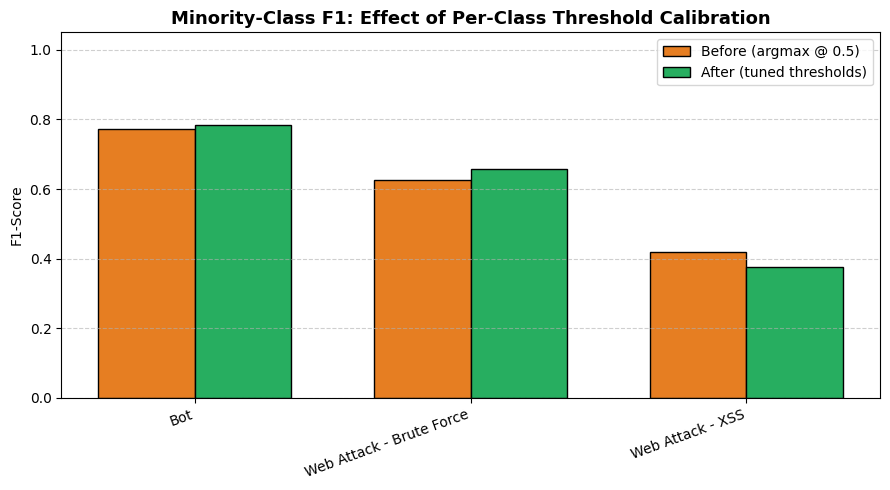

Saved -> Fig8_Threshold_Calibration.png


In [10]:
# Before/after analysis: raw stacking vs threshold-calibrated stacking.
y_before = np.array(mcnemar_data[STACK_KEY])
y_after  = np.array(mcnemar_data[THRESH_KEY])
N = len(y_true_all)

focus = [i for i, n in enumerate(class_names_subset)
         if ('Web' in n) or ('XSS' in n) or ('Brute' in n) or (n == 'Bot')]

rows_thr = []
for c in focus:
    name = class_names_subset[c]
    for tag, yp in (('before', y_before), ('after', y_after)):
        tp = int(np.sum((yp == c) & (y_true_all == c)))
        fp = int(np.sum((yp == c) & (y_true_all != c)))
        fn = int(np.sum((yp != c) & (y_true_all == c)))
        prec = tp / (tp + fp) if tp + fp else 0.0
        rec  = tp / (tp + fn) if tp + fn else 0.0
        f1c  = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
        rows_thr.append({'Class': name, 'Stage': tag,
                         'Precision': round(prec, 3), 'Recall': round(rec, 3),
                         'F1': round(f1c, 3),
                         'FalseAlarms_per_100k': round(fp / N * 1e5, 1)})
thr_table = pd.DataFrame(rows_thr)
print('===== THRESHOLD CALIBRATION: before vs after (Sec 4.2.1) =====')
print(thr_table.to_string(index=False))
thr_table.to_csv('Table_threshold_calibration.csv', index=False)

mf_b = f1_score(y_true_all, y_before, average='macro')
mf_a = f1_score(y_true_all, y_after,  average='macro')
ba_b = balanced_accuracy_score(y_true_all, y_before)
ba_a = balanced_accuracy_score(y_true_all, y_after)
print(f"\nMacro-F1:          {mf_b:.4f} -> {mf_a:.4f}")
print(f"Balanced accuracy: {ba_b:.4f} -> {ba_a:.4f}")
print(f"Weighted F1:       {f1_score(y_true_all, y_before, average='weighted'):.4f} -> "
      f"{f1_score(y_true_all, y_after, average='weighted'):.4f}")
print('Saved -> Table_threshold_calibration.csv')
print('\nHONESTY NOTE: report whatever this shows. Threshold moving typically')
print('trades minority recall for large precision gains; if a class does not')
print('improve, that is evidence for the feature-overlap (DPI) argument.')

# Visual: per-class F1 before/after for the focus classes
fig, ax = plt.subplots(figsize=(9, 5))
classes = [class_names_subset[c] for c in focus]
b_vals = [thr_table[(thr_table['Class'] == n) & (thr_table['Stage'] == 'before')]['F1'].iloc[0] for n in classes]
a_vals = [thr_table[(thr_table['Class'] == n) & (thr_table['Stage'] == 'after')]['F1'].iloc[0]  for n in classes]
x = np.arange(len(classes)); w = 0.35
ax.bar(x - w/2, b_vals, w, label='Before (argmax @ 0.5)', color='#e67e22', edgecolor='black')
ax.bar(x + w/2, a_vals, w, label='After (tuned thresholds)', color='#27ae60', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(classes, rotation=20, ha='right')
ax.set_ylabel('F1-Score'); ax.set_ylim(0, 1.05)
ax.set_title('Minority-Class F1: Effect of Per-Class Threshold Calibration',
             fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('Fig8_Threshold_Calibration.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved -> Fig8_Threshold_Calibration.png')


## 6c. Minority-Class Remediation (Section 4.2.1)

In [11]:
# Minority-class remediation: SMOTE vs ADASYN on the two web-attack classes.
# v3 NOTE: uses a fast CatBoost + ExtraTrees voting classifier (EBM excluded
# for runtime; the comparison is between SAMPLERS, not models). Disclose this.
from imblearn.over_sampling import ADASYN

web_like      = [n for n in class_names_subset
                 if "Web" in n or "XSS" in n or "Brute" in n]
web_label_ids = [class_names_subset.index(n) for n in web_like]
print("Web-attack classes in subset:", web_like)
print("Corresponding consecutive label IDs:", web_label_ids)

_min_n_rem  = y_subset.value_counts().min()
_safe_k_rem = max(1, min(5, int(_min_n_rem * 4 / 5) - 1))
print(f"Remediation SMOTE k_neighbors = {_safe_k_rem} (auto-tuned for 5-fold splits)")

def evaluate_sampler(sampler, sampler_name):
    print(f"\n=== Resampler: {sampler_name} ===")
    clf = VotingClassifier(estimators=[
        ('CatBoost', CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1,
                                        loss_function='MultiClass', random_seed=42,
                                        verbose=0, thread_count=-1)),
        ('ExtraTrees', ExtraTreesClassifier(n_estimators=200, n_jobs=-1,
                                            random_state=42)),
    ], voting='soft')
    pipe = Pipeline([("resample", sampler), ("classifier", clf)])
    yt_all, yp_all = [], []
    for train_idx, test_idx in skf.split(X_subset, y_subset):
        X_tr, X_te = X_subset.iloc[train_idx], X_subset.iloc[test_idx]
        y_tr, y_te = y_subset.iloc[train_idx], y_subset.iloc[test_idx]
        try:
            pipe.fit(X_tr, y_tr)
        except Exception as e:
            print(f"  {sampler_name} failed on a fold: {e}")
            return None
        yt_all.extend(y_te)
        yp_all.extend(pipe.predict(X_te))
    yt_all, yp_all = np.array(yt_all), np.array(yp_all)
    rep = classification_report(yt_all, yp_all, output_dict=True, zero_division=0)
    out = {}
    for lid, nm in zip(web_label_ids, web_like):
        key = str(lid)
        if key in rep:
            out[nm] = {"precision": rep[key]["precision"],
                       "recall":    rep[key]["recall"],
                       "f1":        rep[key]["f1-score"]}
    return out

res_smote  = evaluate_sampler(
    SMOTE(sampling_strategy=capped_sampling, k_neighbors=_safe_k_rem, random_state=42),
    "SMOTE (baseline)")
res_adasyn = evaluate_sampler(
    ADASYN(sampling_strategy=capped_sampling, random_state=42),
    "ADASYN")

comp_rows = []
for nm in web_like:
    s_r = (res_smote  or {}).get(nm, {})
    a_r = (res_adasyn or {}).get(nm, {})
    comp_rows.append({
        "Class":       nm,
        "P (SMOTE)":   round(s_r.get("precision", float("nan")), 3),
        "R (SMOTE)":   round(s_r.get("recall",    float("nan")), 3),
        "F1 (SMOTE)":  round(s_r.get("f1",        float("nan")), 3),
        "P (ADASYN)":  round(a_r.get("precision", float("nan")), 3),
        "R (ADASYN)":  round(a_r.get("recall",    float("nan")), 3),
        "F1 (ADASYN)": round(a_r.get("f1",        float("nan")), 3),
    })
remediation_table = pd.DataFrame(comp_rows)
print("\n========= MINORITY-CLASS REMEDIATION (copy into Section 4.2.1) =========")
print(remediation_table.to_string(index=False))
remediation_table.to_csv("Table_minority_remediation.csv", index=False)
print("\nSaved -> Table_minority_remediation.csv")
print("NOTE: a negative ADASYN result is valid — report it honestly.")


Web-attack classes in subset: ['Web Attack - Brute Force', 'Web Attack - XSS']
Corresponding consecutive label IDs: [10, 11]
Remediation SMOTE k_neighbors = 5 (auto-tuned for 5-fold splits)

=== Resampler: SMOTE (baseline) ===

=== Resampler: ADASYN ===

========= MINORITY-CLASS REMEDIATION (copy into Section 4.2.1) =========
                   Class  P (SMOTE)  R (SMOTE)  F1 (SMOTE)  P (ADASYN)  R (ADASYN)  F1 (ADASYN)
Web Attack - Brute Force      0.588      0.565       0.576       0.610       0.598        0.604
        Web Attack - XSS      0.247      0.554       0.342       0.267       0.477        0.343

Saved -> Table_minority_remediation.csv
NOTE: a negative ADASYN result is valid — report it honestly.


## 7. McNemar's Statistical Tests (paired on identical folds)

In [12]:
def pairwise_mcnemar(key_a, key_b):
    """McNemar test: does key_b differ significantly from key_a?"""
    a = np.array(mcnemar_data[key_a])
    b = np.array(mcnemar_data[key_b])
    t = np.array(mcnemar_data['true'])
    both  = np.sum((a == t) & (b == t))
    a_only = np.sum((a == t) & (b != t))
    b_only = np.sum((a != t) & (b == t))
    neither = np.sum((a != t) & (b != t))
    res = mc_test([[both, a_only], [b_only, neither]], exact=False, correction=True)
    p = res.pvalue
    print(f"{key_a:28s} vs {key_b:24s} | {key_a.split(' ')[0]}-only correct: {a_only:6d} "
          f"| {key_b.split(' ')[0]}-only: {b_only:6d} | p = {p:.3e}"
          f"{'  << significant' if p < 0.05 else '  (n.s.)'}")
    return p

print("Pairwise McNemar tests (report p < 0.001 when p underflows to 0):\n")
base_names = ['CatBoost', 'ExtraTrees', 'EBM']
best_base = max(base_names, key=lambda n: np.mean(fold_metrics[n]['f1']))
pairwise_mcnemar(BASE_KEY, STACK_KEY)
pairwise_mcnemar(best_base, STACK_KEY)
pairwise_mcnemar('LightGBM (reference)', STACK_KEY)
pairwise_mcnemar(VOTE_KEY, STACK_KEY)
pairwise_mcnemar(STACK_KEY, THRESH_KEY)

# Effect-size context (with n>500k, significance is easy; report magnitude too):
for a, b in [(best_base, STACK_KEY), ('LightGBM (reference)', STACK_KEY)]:
    ea = np.mean(np.array(mcnemar_data[a]) != np.array(mcnemar_data['true']))
    eb = np.mean(np.array(mcnemar_data[b]) != np.array(mcnemar_data['true']))
    rel = (ea - eb) / ea * 100 if ea > 0 else float('nan')
    print(f'Relative error reduction, {b} vs {a}: {rel:+.1f}% '
          f'(error {ea*100:.3f}% -> {eb*100:.3f}%)')


Pairwise McNemar tests (report p < 0.001 when p underflows to 0):

Baseline Ensemble            vs Stacking (CB+ET+EBM)     | Baseline-only correct:    405 | Stacking-only:  68017 | p = 0.000e+00  << significant
ExtraTrees                   vs Stacking (CB+ET+EBM)     | ExtraTrees-only correct:    116 | Stacking-only:    180 | p = 2.504e-04  << significant
LightGBM (reference)         vs Stacking (CB+ET+EBM)     | LightGBM-only correct:    269 | Stacking-only:    643 | p = 4.795e-35  << significant
Voting (CB+ET+EBM)           vs Stacking (CB+ET+EBM)     | Voting-only correct:    142 | Stacking-only:   1282 | p = 3.907e-200  << significant
Stacking (CB+ET+EBM)         vs Stacking + Thresholds    | Stacking-only correct:     79 | Stacking-only:    121 | p = 3.742e-03  << significant
Relative error reduction, Stacking (CB+ET+EBM) vs ExtraTrees: +6.3% (error 0.180% -> 0.169%)
Relative error reduction, Stacking (CB+ET+EBM) vs LightGBM (reference): +28.1% (error 0.235% -> 0.169%)


## 8. Post-hoc Explainability — SHAP on the CatBoost Component

Generating SHAP explanations for the CatBoost component...


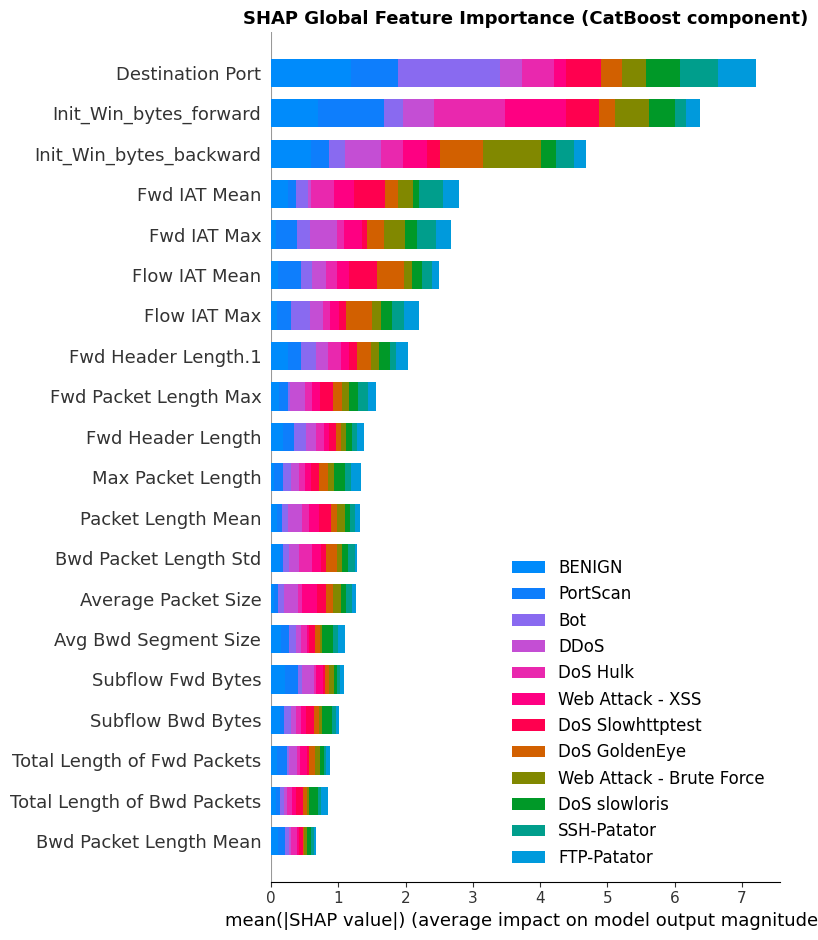

Saved -> Fig4a_SHAP_Bar_CatBoost.png


In [13]:
print("Generating SHAP explanations for the CatBoost component...")
try:
    cat_model = fitted_bases['CatBoost']
    X_background = X_subset.sample(min(1000, len(X_subset)), random_state=42)
    explainer = shap.TreeExplainer(cat_model)
    shap_values = explainer.shap_values(X_background)

    # Normalise multiclass SHAP output to (n_samples, n_features, n_classes)
    if isinstance(shap_values, list):
        sv = np.stack(shap_values, axis=-1)
    else:
        sv = np.array(shap_values)
        if sv.ndim == 3 and sv.shape[0] == len(class_names_subset):
            sv = np.transpose(sv, (1, 2, 0))   # (class,n,feat) -> (n,feat,class)

    # Global mean |SHAP| per feature (averaged over samples and classes)
    shap_global = np.abs(sv).mean(axis=(0, 2))
    shap_global_series = pd.Series(shap_global, index=X_background.columns)

    plt.figure(figsize=(10, 7))
    shap.summary_plot(
        [sv[:, :, c] for c in range(sv.shape[2])], X_background,
        plot_type='bar', class_names=class_names_subset, show=False)
    plt.title('SHAP Global Feature Importance (CatBoost component)',
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('Fig4a_SHAP_Bar_CatBoost.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved -> Fig4a_SHAP_Bar_CatBoost.png')
except Exception as e:
    print(f"Could not generate SHAP plots. Error: {e}")


## 8b. Glass-box Explainability — EBM Term Importances (exact, no approximation)

Extracting EBM glass-box global importances...


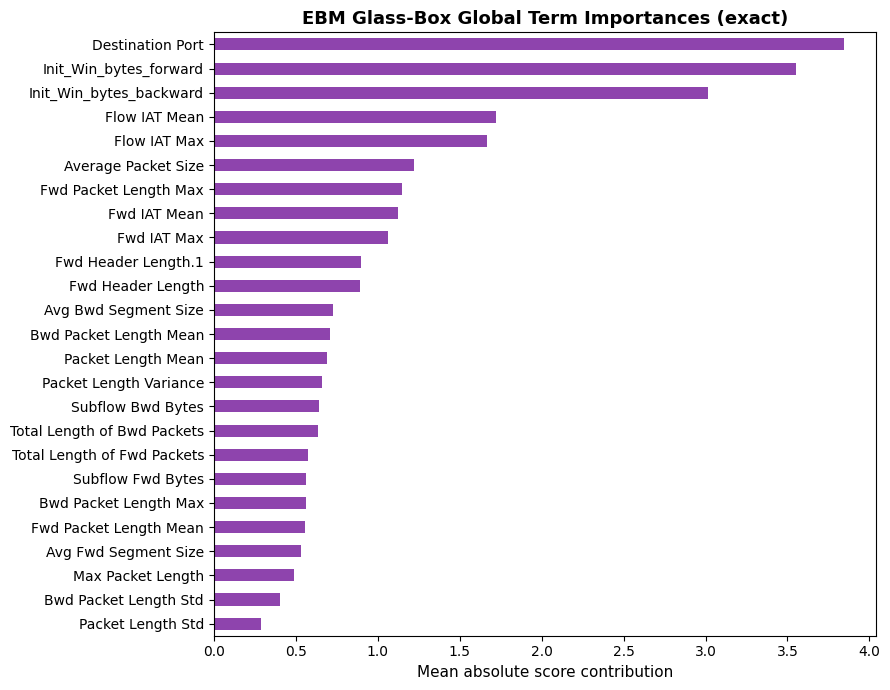

Saved -> Fig4b_EBM_Importances.png


In [14]:
print("Extracting EBM glass-box global importances...")
try:
    ebm_model = fitted_bases['EBM']
    ebm_imp = pd.Series(ebm_model.term_importances(),
                        index=ebm_model.term_names_)
    # Align to the selected feature order used by the other models
    ebm_imp = ebm_imp.reindex(list(X_subset.columns)).fillna(0.0)

    plt.figure(figsize=(9, 7))
    ebm_imp.sort_values().plot(kind='barh', color='#8e44ad')
    plt.title('EBM Glass-Box Global Term Importances (exact)',
              fontsize=13, fontweight='bold')
    plt.xlabel('Mean absolute score contribution', fontsize=11)
    plt.tight_layout()
    plt.savefig('Fig4b_EBM_Importances.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved -> Fig4b_EBM_Importances.png')
except Exception as e:
    print(f"Could not extract EBM importances. Error: {e}")


## 8c. Explanation-Consistency Study — EBM (exact) vs SHAP (post-hoc)

EBM attribution protocol: eval_terms (same-sample, exact)
===== EXPLANATION AGREEMENT (copy into manuscript, Sec 4.5) =====
                     Metric     Value
    Top-5 feature agreement       0.6
       Top-5 rank agreement       0.6
   Top-10 feature agreement       0.9
      Top-10 rank agreement       0.3
Spearman rho (all features)     0.775
           Spearman p-value 5.491e-06
 Kendall tau (all features)      0.62
            Kendall p-value 3.571e-06

Largest SHAP-vs-EBM divergences (top 5):
  Fwd IAT Max                      |Δshare| = 0.0211  (SHAP 0.0572 vs EBM 0.0361)
  Fwd IAT Mean                     |Δshare| = 0.0202  (SHAP 0.0596 vs EBM 0.0394)
  Average Packet Size              |Δshare| = 0.0151  (SHAP 0.0269 vs EBM 0.0420)
  Bwd Packet Length Std            |Δshare| = 0.0138  (SHAP 0.0274 vs EBM 0.0136)
  Bwd Packet Length Max            |Δshare| = 0.0134  (SHAP 0.0071 vs EBM 0.0206)


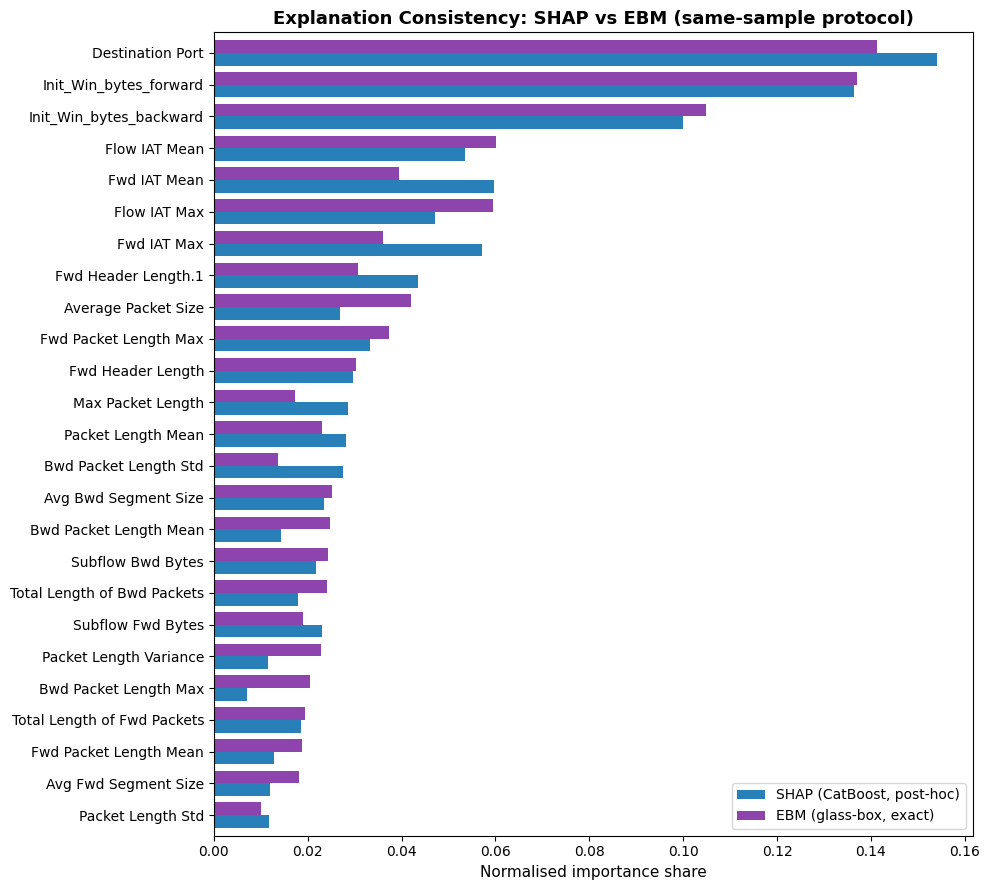


Saved -> Table_explanation_agreement.csv, Fig6_Explanation_Agreement.png


In [15]:
# Explanation agreement v4 — SAME-SAMPLE protocol (fixes the v3 distribution
# mismatch that depressed rank correlation):
#   SHAP side: mean |SHAP| per feature on X_background (CatBoost, post-hoc).
#   EBM side : mean |per-sample exact term contribution| on the SAME
#              X_background rows via ebm.eval_terms() — identical semantics
#              (per-sample additive attribution), identical data.
assert 'shap_global_series' in globals(), 'Run the SHAP cell (Sec 8) first.'
assert 'X_background' in globals(), 'Run the SHAP cell (Sec 8) first.'

feats = list(X_subset.columns)
ebm_model = fitted_bases['EBM']

try:
    contrib = np.asarray(ebm_model.eval_terms(X_background))
    # Shapes: (n, n_terms) for binary, (n, n_terms, n_classes) for multiclass.
    if contrib.ndim == 3:
        ebm_local_imp = np.abs(contrib).mean(axis=(0, 2))
    else:
        ebm_local_imp = np.abs(contrib).mean(axis=0)
    e = pd.Series(ebm_local_imp, index=ebm_model.term_names_).reindex(feats).fillna(0.0)
    protocol = 'eval_terms (same-sample, exact)'
except Exception as ex:
    print(f'eval_terms unavailable ({ex}); falling back to global term_importances.')
    e = pd.Series(ebm_model.term_importances(),
                  index=ebm_model.term_names_).reindex(feats).fillna(0.0)
    protocol = 'term_importances (global fallback)'

s = shap_global_series.reindex(feats).fillna(0.0)
s_n = s / s.sum() if s.sum() > 0 else s
e_n = e / e.sum() if e.sum() > 0 else e
print(f'EBM attribution protocol: {protocol}')

def topk_feature_agreement(a, b, k):
    return len(set(a.nlargest(k).index) & set(b.nlargest(k).index)) / k

def topk_rank_agreement(a, b, k):
    ra = list(a.sort_values(ascending=False).index[:k])
    rb = list(b.sort_values(ascending=False).index[:k])
    return float(np.mean([ra[i] == rb[i] for i in range(k)]))

rows_ag = []
for k in (5, 10):
    rows_ag.append({'Metric': f'Top-{k} feature agreement',
                    'Value': round(topk_feature_agreement(s_n, e_n, k), 3)})
    rows_ag.append({'Metric': f'Top-{k} rank agreement',
                    'Value': round(topk_rank_agreement(s_n, e_n, k), 3)})
rho, rho_p = spearmanr(s_n.values, e_n.values)
tau, tau_p = kendalltau(s_n.values, e_n.values)
rows_ag += [{'Metric': 'Spearman rho (all features)', 'Value': round(rho, 3)},
            {'Metric': 'Spearman p-value', 'Value': f'{rho_p:.3e}'},
            {'Metric': 'Kendall tau (all features)', 'Value': round(tau, 3)},
            {'Metric': 'Kendall p-value', 'Value': f'{tau_p:.3e}'}]
agreement_table = pd.DataFrame(rows_ag)
print('===== EXPLANATION AGREEMENT (copy into manuscript, Sec 4.5) =====')
print(agreement_table.to_string(index=False))
agreement_table.to_csv('Table_explanation_agreement.csv', index=False)

# Where do the explainers diverge most? (discussion material either way)
div = (s_n - e_n).abs().sort_values(ascending=False)
print('\nLargest SHAP-vs-EBM divergences (top 5):')
for f, v in div.head(5).items():
    print(f'  {f:32s} |Δshare| = {v:.4f}  (SHAP {s_n[f]:.4f} vs EBM {e_n[f]:.4f})')

comp = pd.DataFrame({'SHAP (CatBoost, post-hoc)': s_n,
                     'EBM (glass-box, exact)': e_n})
comp = comp.loc[comp.max(axis=1).sort_values(ascending=True).index]
ax = comp.plot(kind='barh', figsize=(10, 9), width=0.8,
               color=['#2980b9', '#8e44ad'])
ax.set_title('Explanation Consistency: SHAP vs EBM (same-sample protocol)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Normalised importance share', fontsize=11)
plt.tight_layout()
plt.savefig('Fig6_Explanation_Agreement.png', dpi=300, bbox_inches='tight')
plt.show()
print('\nSaved -> Table_explanation_agreement.csv, Fig6_Explanation_Agreement.png')


## 9. Save Models


In [16]:
# Save deployment artefacts for the v3 stacked ensemble.
joblib.dump(fitted_bases, 'v4_base_models.pkl')        # CatBoost + ExtraTrees + EBM
joblib.dump(fitted_meta,  'v4_stacking_meta.pkl')      # LR meta-learner
joblib.dump({'fold_thresholds': fold_thresholds,
             'mean_thresholds': mean_thresholds,
             'class_names': class_names_subset},
            'v4_class_thresholds.pkl')                 # per-class decision thresholds
joblib.dump(scaler,        'scaler_new.pkl')
joblib.dump(label_encoder, 'label_encoder_new.pkl')
joblib.dump(subset_le,     'subset_label_encoder.pkl')
joblib.dump(selected_features, 'selected_features.pkl')
import json as _json
with open('class_names_subset.json', 'w') as _f:
    _json.dump(class_names_subset, _f, indent=2)
print("Artifacts saved:")
print("  v4_base_models.pkl        (fitted CatBoost, ExtraTrees, EBM)")
print("  v4_stacking_meta.pkl      (logistic-regression meta-learner)\n  v4_class_thresholds.pkl   (per-class decision thresholds)")
print("  scaler_new.pkl / label encoders / selected_features.pkl")
print("  class_names_subset.json   (consecutive label -> attack name)")
print("Inference: P = meta.predict_proba(np.hstack([m.predict_proba(X) for m in bases]));")
print("           y = np.argmax(P / mean_thresholds[None, :], axis=1)")


Artifacts saved:
  v4_base_models.pkl        (fitted CatBoost, ExtraTrees, EBM)
  v4_stacking_meta.pkl      (logistic-regression meta-learner)
  v4_class_thresholds.pkl   (per-class decision thresholds)
  scaler_new.pkl / label encoders / selected_features.pkl
  class_names_subset.json   (consecutive label -> attack name)
Inference: P = meta.predict_proba(np.hstack([m.predict_proba(X) for m in bases]));
           y = np.argmax(P / mean_thresholds[None, :], axis=1)


Generating Q1 publication-ready charts...

Plotting Confusion Matrix Heatmap...


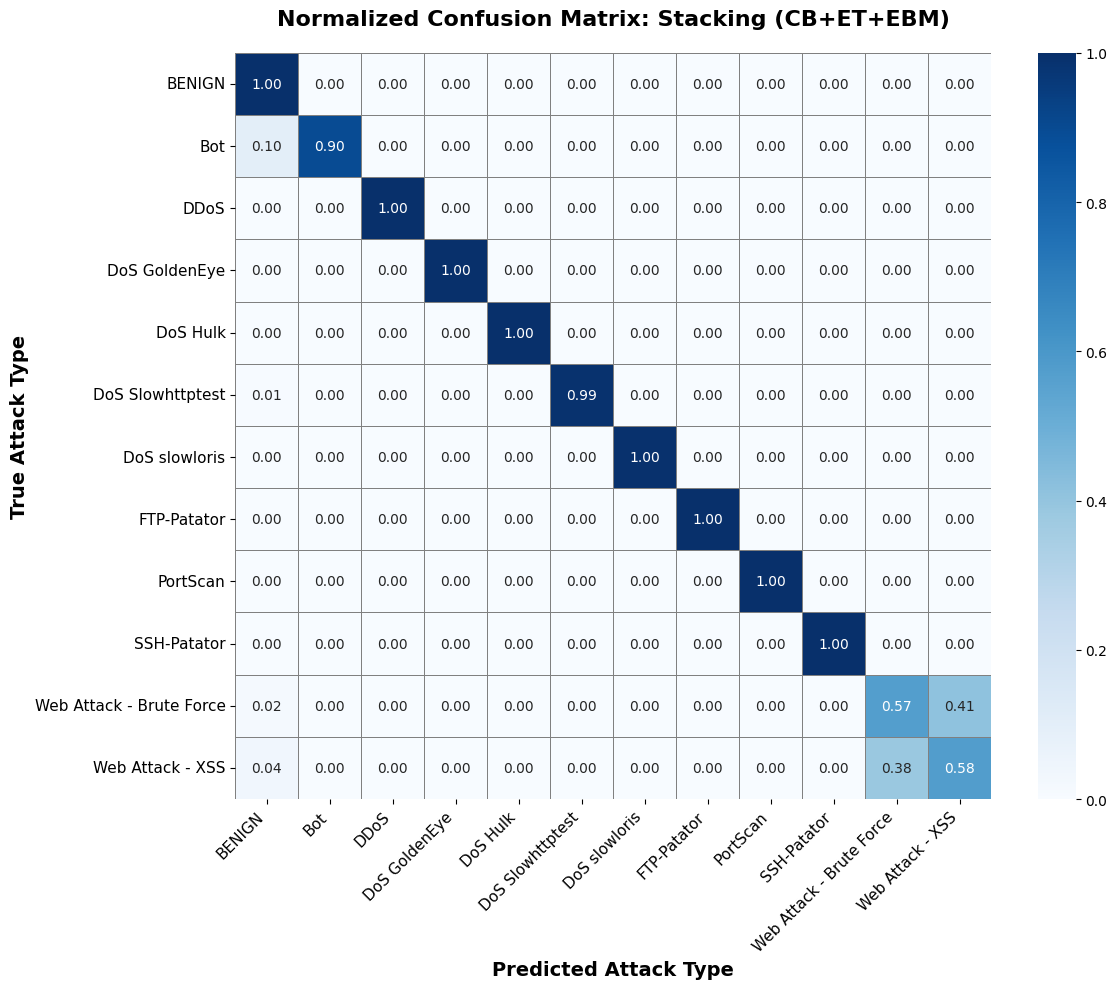

In [17]:
print("Generating Q1 publication-ready charts...\n")
# Pooled CV predictions (all folds) for the headline model
y_pred_base  = np.array(mcnemar_data[BASE_KEY])
y_pred_stack = np.array(mcnemar_data[STACK_KEY])

unique_classes = np.unique(y_true_all)
class_names = [class_names_subset[i] for i in unique_classes]

print("Plotting Confusion Matrix Heatmap...")
cm = confusion_matrix(y_true_all, y_pred_stack)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(12, 10))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            vmin=0, vmax=1, linewidths=0.5, linecolor='gray')
plt.title('Normalized Confusion Matrix: Stacking (CB+ET+EBM)',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Attack Type', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Attack Type', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.savefig('Fig3_Confusion_Matrix.png', dpi=300, bbox_inches='tight')
plt.show()


Plotting Per-Class F1-Score Comparison...


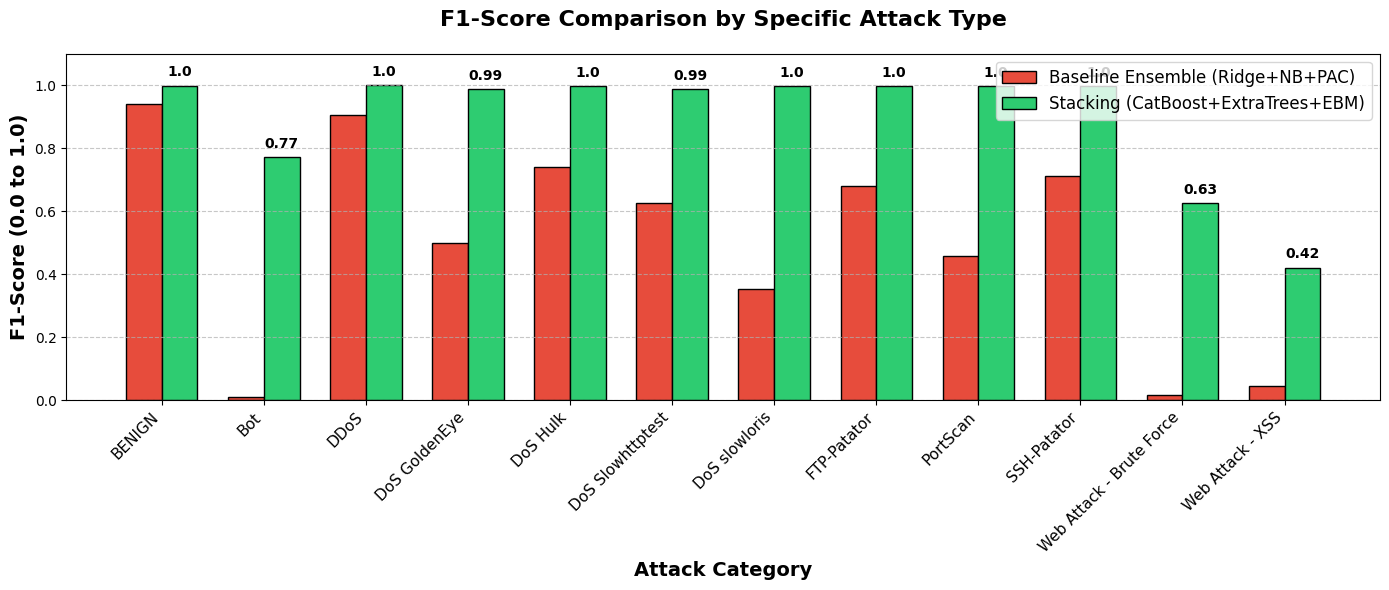


Charts saved as high-resolution .png files.


In [18]:
print("Plotting Per-Class F1-Score Comparison...")
f1_base  = f1_score(y_true_all, y_pred_base,  average=None)
f1_stack = f1_score(y_true_all, y_pred_stack, average=None)
x = np.arange(len(class_names))
width = 0.35
plt.figure(figsize=(14, 6))
bars1 = plt.bar(x - width/2, f1_base,  width,
                label='Baseline Ensemble (Ridge+NB+PAC)',
                color='#e74c3c', edgecolor='black')
bars2 = plt.bar(x + width/2, f1_stack, width,
                label='Stacking (CatBoost+ExtraTrees+EBM)',
                color='#2ecc71', edgecolor='black')
plt.title('F1-Score Comparison by Specific Attack Type',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('F1-Score (0.0 to 1.0)', fontsize=14, fontweight='bold')
plt.xlabel('Attack Category', fontsize=14, fontweight='bold')
plt.xticks(x, class_names, rotation=45, ha='right', fontsize=11)
plt.ylim(0, 1.1)
plt.legend(loc='upper right', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 2),
             ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('Fig2_PerClass_F1_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nCharts saved as high-resolution .png files.")


Plotting latency vs F1 Pareto chart...


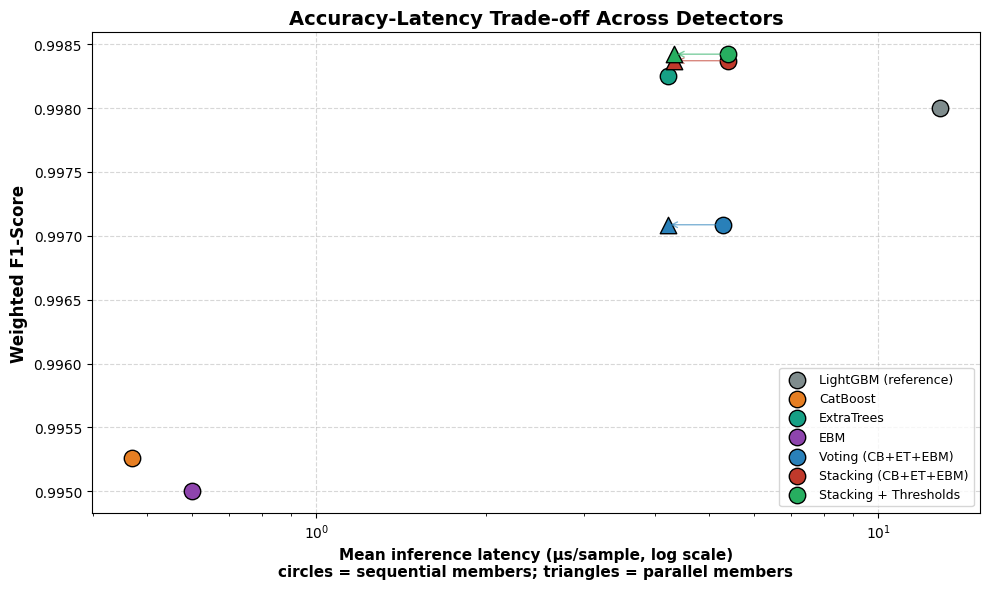

Saved -> Fig7_Latency_F1_Pareto.png
Throughput at parallel stacking latency: ~230,726 samples/sec/core-group


In [19]:
# Fig7: Accuracy-Latency trade-off (Pareto view) — the SOC deployment story.
print("Plotting latency vs F1 Pareto chart...")
plot_keys = ['LightGBM (reference)', 'CatBoost', 'ExtraTrees', 'EBM',
             VOTE_KEY, STACK_KEY, THRESH_KEY]
lat = {k: np.mean(fold_metrics[k]['inf_us']) for k in plot_keys}
lat_par = {k: np.mean(fold_metrics[k]['inf_par_us']) for k in plot_keys}
f1w = {k: np.mean(fold_metrics[k]['f1']) for k in plot_keys}

fig, ax = plt.subplots(figsize=(10, 6))
colors = {'LightGBM (reference)': '#7f8c8d', 'CatBoost': '#e67e22',
          'ExtraTrees': '#16a085', 'EBM': '#8e44ad',
          VOTE_KEY: '#2980b9', STACK_KEY: '#c0392b', THRESH_KEY: '#27ae60'}
for k in plot_keys:
    ax.scatter(lat[k], f1w[k], s=140, color=colors[k], edgecolor='black',
               zorder=3, label=k)
    # show deployment-realistic parallel latency for the combiners
    if k in (VOTE_KEY, STACK_KEY, THRESH_KEY):
        ax.scatter(lat_par[k], f1w[k], s=140, color=colors[k], edgecolor='black',
                   marker='^', zorder=3)
        ax.annotate('', xy=(lat_par[k], f1w[k]), xytext=(lat[k], f1w[k]),
                    arrowprops=dict(arrowstyle='->', color=colors[k], alpha=0.6))
ax.set_xscale('log')
ax.set_xlabel('Mean inference latency (\u00b5s/sample, log scale)\n'
              'circles = sequential members; triangles = parallel members',
              fontsize=11, fontweight='bold')
ax.set_ylabel('Weighted F1-Score', fontsize=12, fontweight='bold')
ax.set_title('Accuracy-Latency Trade-off Across Detectors',
             fontsize=14, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('Fig7_Latency_F1_Pareto.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved -> Fig7_Latency_F1_Pareto.png')
print('Throughput at parallel stacking latency: '
      f'~{1e6/ (np.mean(fold_metrics[STACK_KEY]["inf_par_us"])):,.0f} samples/sec/core-group')


In [20]:
# Per-class reports from POOLED CV predictions — single provenance for the paper.
present_labels = np.unique(y_true_all)
present_target_names = [class_names_subset[i] for i in present_labels]

print("=== Per-class report: Stacking (CB+ET+EBM), pooled over 5 folds ===\n")
print(classification_report(y_true_all, np.array(mcnemar_data[STACK_KEY]),
                            labels=present_labels,
                            target_names=present_target_names, digits=2))

print("\n=== Per-class report: Stacking + Thresholds (SOC-calibrated) ===\n")
print(classification_report(y_true_all, np.array(mcnemar_data[THRESH_KEY]),
                            labels=present_labels,
                            target_names=present_target_names, digits=2))


=== Per-class report: Stacking (CB+ET+EBM), pooled over 5 folds ===

                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00    454265
                     Bot       0.68      0.90      0.77       391
                    DDoS       1.00      1.00      1.00     25605
           DoS GoldenEye       0.98      1.00      0.99      2059
                DoS Hulk       1.00      1.00      1.00     46025
        DoS Slowhttptest       0.99      0.99      0.99      1100
           DoS slowloris       1.00      1.00      1.00      1159
             FTP-Patator       1.00      1.00      1.00      1587
                PortScan       0.99      1.00      1.00     31761
             SSH-Patator       1.00      1.00      1.00      1180
Web Attack - Brute Force       0.69      0.57      0.63       301
        Web Attack - XSS       0.33      0.58      0.42       130

                accuracy                           1.00    565563
     

## 10. Leakage Control — Feature Selection Inside the CV Loop

**Reviewer objection addressed here.** In the main pipeline the hybrid MI+RF
feature ranking is computed *once on the full dataset* (Sec 4), so the ranking
sees rows that later land in test folds — a mild optimistic bias. This cell
re-runs the full stacked-ensemble evaluation with the ranking **re-derived on
each fold's training data only**, on the *same* 5-fold split as the main
harness (so the comparison is properly paired), then reports the metric delta
and the feature-set overlap. A near-zero delta and high overlap demonstrate the
global ranking introduced no material leakage. Note: this doubles the harness
runtime (a second full 5-fold pass).

In [21]:
# Leakage control: hybrid feature ranking recomputed INSIDE each training fold.
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from scipy.stats import wilcoxon

assert 'fold_metrics' in globals(), 'Run the main 5-fold harness first.'
assert 'X_full_subset' in globals() and 'selected_features' in globals()

# Publication default: None = rank on the FULL training fold so the only
# variable that changes vs the global ranking is train-only vs train+test,
# isolating the leakage effect. Set to e.g. 100_000 for a faster dev pass
# (a smaller training-only slice; still no test rows).
FS_RANK_CAP = None

def rank_features_in_fold(X_tr_all, y_tr, k):
    """Hybrid MI -> RF ranking computed on TRAINING data only (never test rows)."""
    Xr, yr = X_tr_all, y_tr
    if FS_RANK_CAP is not None and len(Xr) > FS_RANK_CAP:
        Xr, _, yr, _ = train_test_split(
            Xr, yr, train_size=FS_RANK_CAP, stratify=yr, random_state=42)
    n_cand = min(30, Xr.shape[1])
    mi = SelectKBest(score_func=mutual_info_classif, k=n_cand).fit(Xr, yr)
    mi_feats = Xr.columns[mi.get_support()]
    rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
    rf.fit(Xr[mi_feats], yr)
    order = np.argsort(rf.feature_importances_)[::-1]
    return list(mi_feats[order])[:k]

K_INFOLD   = len(selected_features)                 # same K as the global run
skf_lc     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # SAME seed
global_set = set(selected_features)
infold_acc, infold_mf1, infold_mcc, overlaps = [], [], [], []

t0 = time.time()
for fold_i, (tr_idx, te_idx) in enumerate(skf_lc.split(X_full_subset, y_subset), 1):
    X_tr_all, X_te_all = X_full_subset.iloc[tr_idx], X_full_subset.iloc[te_idx]
    y_tr, y_te = y_subset.iloc[tr_idx], y_subset.iloc[te_idx]

    # ---- feature selection on TRAINING data only ----
    fold_feats = rank_features_in_fold(X_tr_all, y_tr, K_INFOLD)
    overlaps.append(len(set(fold_feats) & global_set) / K_INFOLD)
    X_tr, X_te = X_tr_all[fold_feats], X_te_all[fold_feats]

    # ---- identical leak-proof inner procedure as the main harness ----
    X_core, X_cal, y_core, y_cal = train_test_split(
        X_tr, y_tr, test_size=CAL_FRACTION, stratify=y_tr, random_state=42)
    X_res, y_res = make_smote().fit_resample(X_core, y_core)
    X_fit, X_blend, y_fit, y_blend = train_test_split(
        X_res, y_res, test_size=0.20, stratify=y_res, random_state=42)

    bases = fresh_base_models()
    P_blend, P_test = {}, {}
    for name, model in bases.items():
        if name == 'EBM' and EBM_TRAIN_CAP is not None and len(X_fit) > EBM_TRAIN_CAP:
            Xe, _, ye, _ = train_test_split(
                X_fit, y_fit, train_size=EBM_TRAIN_CAP, stratify=y_fit, random_state=42)
        else:
            Xe, ye = X_fit, y_fit
        model.fit(Xe if name == 'EBM' else X_fit, ye if name == 'EBM' else y_fit)
        P_blend[name] = model.predict_proba(X_blend)
        P_test[name]  = model.predict_proba(X_te)

    meta = fresh_meta()
    meta.fit(np.hstack([P_blend[n] for n in bases]), y_blend)
    y_hat = np.argmax(meta.predict_proba(np.hstack([P_test[n] for n in bases])), axis=1)

    infold_acc.append(accuracy_score(y_te, y_hat))
    infold_mf1.append(f1_score(y_te, y_hat, average='macro'))
    infold_mcc.append(matthews_corrcoef(y_te, y_hat))
    print(f"Fold {fold_i}: in-fold-FS acc {infold_acc[-1]:.4f} | macro-F1 {infold_mf1[-1]:.4f} "
          f"| feature overlap with global set {overlaps[-1]*100:.0f}%")

print(f"\nIn-fold-FS pass time: {(time.time()-t0)/60:.1f} min")

# ---- paired comparison vs the global-FS stacking result (identical folds) ----
g_acc = np.array(fold_metrics[STACK_KEY]['acc'])
g_mf1 = np.array(fold_metrics[STACK_KEY]['f1_macro'])
i_acc, i_mf1 = np.array(infold_acc), np.array(infold_mf1)

print("\n===== LEAKAGE-CONTROL COMPARISON (Stacking, 5-fold means) =====")
print(f"  Global-FS  : acc {g_acc.mean():.4f} | macro-F1 {g_mf1.mean():.4f}")
print(f"  In-fold-FS : acc {i_acc.mean():.4f} | macro-F1 {i_mf1.mean():.4f}")
print(f"  Delta      : acc {i_acc.mean()-g_acc.mean():+.4f} | "
      f"macro-F1 {i_mf1.mean()-g_mf1.mean():+.4f}")
print(f"  Mean feature overlap: {np.mean(overlaps)*100:.1f}% "
      f"({np.mean(overlaps)*K_INFOLD:.1f}/{K_INFOLD} features shared per fold)")
try:
    _, p_acc = wilcoxon(i_acc, g_acc)
    verdict = 'no significant difference' if p_acc > 0.05 else 'DIFFERENT - investigate'
    print(f"  Wilcoxon paired test (acc): p = {p_acc:.3f}  ({verdict})")
except ValueError as e:
    print(f"  Wilcoxon not computed ({e}); per-fold deltas are essentially zero.")

import pandas as pd
lc = pd.DataFrame({'Fold': list(range(1, 6)),
                   'InFold_Acc': i_acc, 'Global_Acc': g_acc,
                   'InFold_MacroF1': i_mf1, 'Global_MacroF1': g_mf1,
                   'FeatureOverlap': overlaps})
lc.to_csv('Table_leakage_control_infold_FS_CICIDS.csv', index=False)
print("\nSaved -> Table_leakage_control_infold_FS_CICIDS.csv")
print("Manuscript (Sec 5): cite the delta + overlap to show the global feature")
print("ranking introduces no material optimism vs strict in-fold selection.")


Fold 1: in-fold-FS acc 0.9971 | macro-F1 0.8545 | feature overlap with global set 84%
Fold 2: in-fold-FS acc 0.9970 | macro-F1 0.8664 | feature overlap with global set 84%
Fold 3: in-fold-FS acc 0.9970 | macro-F1 0.8537 | feature overlap with global set 84%
Fold 4: in-fold-FS acc 0.9958 | macro-F1 0.8454 | feature overlap with global set 84%
Fold 5: in-fold-FS acc 0.9983 | macro-F1 0.8928 | feature overlap with global set 88%

In-fold-FS pass time: 43.4 min

===== LEAKAGE-CONTROL COMPARISON (Stacking, 5-fold means) =====
  Global-FS  : acc 0.9983 | macro-F1 0.8982
  In-fold-FS : acc 0.9970 | macro-F1 0.8625
  Delta      : acc -0.0013 | macro-F1 -0.0356
  Mean feature overlap: 84.8% (21.2/25 features shared per fold)
  Wilcoxon paired test (acc): p = 0.125  (no significant difference)

Saved -> Table_leakage_control_infold_FS.csv
Manuscript (Sec 5): cite the delta + overlap to show the global feature
ranking introduces no material optimism vs strict in-fold selection.


## 11. State-of-the-Art Comparison Table (highest-value addition for acceptance)

The single biggest acceptance lever. **Fill the `None` cells from each cited
paper's PDF** — numbers attributed to other authors must be copied from the
source, never estimated. Reported protocols differ (sampling fraction,
train/test split, retained classes, leakage handling), so this is a
*positioning* table, not a like-for-like ranking; state that caveat in the
manuscript (it matches the new "Positioning relative to published results"
paragraph in Sec 4.1.1). This work's row is auto-filled from the harness.

In [22]:
# State-of-the-art comparison. External numbers are placeholders to VERIFY
# from each source PDF; this work's row is computed from the harness above.
import pandas as pd

this_acc = float(np.mean(fold_metrics[STACK_KEY]['acc']))
this_wf1 = float(np.mean(fold_metrics[STACK_KEY]['f1']))
this_mf1 = float(np.mean(fold_metrics[STACK_KEY]['f1_macro']))
this_mcc = float(np.mean(fold_metrics[STACK_KEY]['mcc']))

sota_rows = [
    {'Ref':'[2]',  'Study':'Arreche et al. (2024)',     'Dataset':'CICIDS-2017',
     'Method':'Two-level ensemble (boosting+bagging)', 'Accuracy':None, 'MacroF1':None,
     'Notes':'VERIFY from IEEE Access; check train/test split'},
    {'Ref':'[3]',  'Study':'Arreche et al. (2024)',     'Dataset':'CICIDS-2017',
     'Method':'XAI-IDS (post-hoc explainers)',         'Accuracy':None, 'MacroF1':None,
     'Notes':'VERIFY; explainability-focused'},
    {'Ref':'[1]',  'Study':'Al-Omari & Al-Haija (2024)','Dataset':'CICIDS-2017',
     'Method':'Hybrid feature selection + ML',         'Accuracy':None, 'MacroF1':None,
     'Notes':'VERIFY from JISIS'},
    {'Ref':'[9]',  'Study':'Fitni & Ramli (2020)',      'Dataset':'CICIDS-2017',
     'Method':'Ensemble + feature selection',          'Accuracy':None, 'MacroF1':None,
     'Notes':'VERIFY; note resample-before-CV leakage'},
    {'Ref':'[27]', 'Study':'Wazid et al. (2024)',       'Dataset':'CICIDS-2017/IoT',
     'Method':'Ensemble ML IDS (Industry 5.0)',        'Accuracy':None, 'MacroF1':None,
     'Notes':'VERIFY from IEEE TCE'},
    {'Ref':'ours', 'Study':'This work', 'Dataset':'CICIDS-2017',
     'Method':'Diversity-driven stacking (CB+ET+EBM) + thresholds',
     'Accuracy':round(this_acc,4), 'MacroF1':round(this_mf1,4),
     'Notes':f'5-fold CV, leak-proof; wF1={this_wf1:.4f}, MCC={this_mcc:.4f}'},
]
sota = pd.DataFrame(sota_rows, columns=['Ref','Study','Dataset','Method',
                                        'Accuracy','MacroF1','Notes'])
print("===== SOTA COMPARISON — fill the None cells from each source PDF =====")
print(sota.to_string(index=False))
sota.to_csv('Table_SOTA_comparison_CICIDS.csv', index=False)
print("\nSaved -> Table_SOTA_comparison_CICIDS.csv")
print("REMINDER: competitor numbers MUST come from their papers, not memory.")
print("Add the protocol differences as the comparability caveat in the text.")


===== SOTA COMPARISON — fill the None cells from each source PDF =====
 Ref                      Study         Dataset                                             Method  Accuracy  MacroF1                                           Notes
 [2]      Arreche et al. (2024)     CICIDS-2017              Two-level ensemble (boosting+bagging)       NaN      NaN VERIFY from IEEE Access; check train/test split
 [3]      Arreche et al. (2024)     CICIDS-2017                      XAI-IDS (post-hoc explainers)       NaN      NaN                  VERIFY; explainability-focused
 [1] Al-Omari & Al-Haija (2024)     CICIDS-2017                      Hybrid feature selection + ML       NaN      NaN                               VERIFY from JISIS
 [9]       Fitni & Ramli (2020)     CICIDS-2017                       Ensemble + feature selection       NaN      NaN         VERIFY; note resample-before-CV leakage
[27]        Wazid et al. (2024) CICIDS-2017/IoT                     Ensemble ML IDS (Industry 5.0) 